In [5]:
%pip install tensorflow scikit-learn pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [6]:
# Optional install if running in a fresh local environment
# %pip install tensorflow matplotlib pandas scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from sklearn.model_selection import train_test_split

# Set seeds for reproducible results
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.22.0-rc0


In [7]:
# Small synthetic 2-class text dataset (Positive = 1, Negative = 0)
texts = [
    # Positive reviews (Class 1)
    "I absolutely loved this movie, it was fantastic and brilliant",
    "Great acting, wonderful plot, and amazing visuals",
    "An excellent film that inspired me greatly",
    "Truly a masterpiece, outstanding performance by the cast",
    "Highly recommended, one of the best films of the year",
    "Superb direction and deeply emotional storyline",
    "A wonderful experience from beginning to end",
    "Engaging, delightful, and thoroughly entertaining",
    "Brilliant cinematography and lovely soundtrack",
    "Loved every single minute of this magnificent movie",
    "Incredible performance and beautifully directed",
    "A heartwarming and joyful masterpiece",
    "Top notch acting and deeply satisfying ending",
    "Extremely well made with great passion and depth",
    "One of my all time favorite movies to watch",
    "A great story told in a fascinating way",
    "Wonderful characters and an inspiring journey",
    "I was amazed by the visual quality and acting",
    "Super entertaining and well written dialogue",
    "Outstanding cinematic experience that I highly recommend",
    
    # Negative reviews (Class 0)
    "This was a terrible movie, completely wasted my time",
    "Awful acting, horrible plot, and terrible pacing",
    "A boring and dull film that put me to sleep",
    "Truly a disaster, the worst movie of the entire year",
    "Do not watch this garbage, it makes no sense at all",
    "Poor direction, messy script, and dreadful acting",
    "A painful experience that I could barely sit through",
    "Annoying, uninspired, and completely predictable",
    "Horrible dialogue and atrocious special effects",
    "Hated every single second of this stupid movie",
    "Disappointing script and dreadful character development",
    "An irritating waste of money and time",
    "Zero effort put into the story and bad acting throughout",
    "Extremely poorly made with no redeeming qualities",
    "One of the worst films I have ever had to watch",
    "A totally confusing story told with zero emotion",
    "Boring characters and an utterly pointless ending",
    "I was annoyed by the cheap effects and terrible sound",
    "Unbearably dull and horribly written dialogue",
    "Terrible disaster that no one should ever watch"
]

labels = [1] * 20 + [0] * 20  # 20 Positive (1), 20 Negative (0)

# Pass lists directly to train_test_split (prevents PyArrow indexing error)
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    texts,
    labels,
    test_size=0.25,
    random_state=SEED,
    stratify=labels
)

# Convert labels to numpy arrays
y_train = np.array(y_train, dtype=np.float32)
y_val = np.array(y_val, dtype=np.float32)

print(f"Total samples: {len(texts)}")
print(f"Training samples: {len(X_train_raw)} | Validation samples: {len(X_val_raw)}")

Total samples: 40
Training samples: 30 | Validation samples: 10


In [8]:
VOCAB_SIZE = 150

# Initialize TextVectorization layer
vectorize_layer = layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode="multi_hot",
    standardize="lower_and_strip_punctuation"
)

# Adapt vectorizer to the training corpus
vectorize_layer.adapt(np.array(X_train_raw))

# Transform text to numerical arrays
X_train = vectorize_layer(np.array(X_train_raw)).numpy()
X_val = vectorize_layer(np.array(X_val_raw)).numpy()

print(f"Input feature dimension: {X_train.shape[1]}")
print(f"Sample transformed text vector shape: {X_train[0].shape}")
print(f"Vocabulary sample (first 10 words): {vectorize_layer.get_vocabulary()[:10]}")

Input feature dimension: 133
Sample transformed text vector shape: (133,)
Vocabulary sample (first 10 words): ['[UNK]', np.str_('and'), np.str_('a'), np.str_('of'), np.str_('the'), np.str_('this'), np.str_('that'), np.str_('terrible'), np.str_('movie'), np.str_('an')]


In [9]:
def build_baseline_model(input_dim):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ], name="Baseline_No_Reg")
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

model_base = build_baseline_model(X_train.shape[1])
model_base.summary()

Model: "Baseline_No_Reg"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │           8,576 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,689 (41.75 KB)

 Trainable params: 10,689 (41.75 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
EPOCHS = 60
BATCH_SIZE = 8

history_base = model_base.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=0
)

print("Baseline Model Training Finished.")
print(f"Final Train Accuracy: {history_base.history['accuracy'][-1]:.4f} | Val Accuracy: {history_base.history['val_accuracy'][-1]:.4f}")
print(f"Final Train Loss:     {history_base.history['loss'][-1]:.4f} | Val Loss:     {history_base.history['val_loss'][-1]:.4f}")

Baseline Model Training Finished.
Final Train Accuracy: 1.0000 | Val Accuracy: 0.5000
Final Train Loss:     0.0001 | Val Loss:     0.9855


In [11]:
def build_dropout_model(input_dim, dropout_rate=0.4):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation="relu"),
        layers.Dropout(dropout_rate),
        layers.Dense(32, activation="relu"),
        layers.Dropout(dropout_rate),
        layers.Dense(1, activation="sigmoid")
    ], name="Model_With_Dropout")
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

model_dropout = build_dropout_model(X_train.shape[1], dropout_rate=0.4)
model_dropout.summary()

Model: "Model_With_Dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 64)                  │           8,576 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,689 (41.75 KB)

 Trainable params: 10,689 (41.75 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history_dropout = model_dropout.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=0
)

print("Dropout Model Training Finished.")
print(f"Final Train Accuracy: {history_dropout.history['accuracy'][-1]:.4f} | Val Accuracy: {history_dropout.history['val_accuracy'][-1]:.4f}")
print(f"Final Train Loss:     {history_dropout.history['loss'][-1]:.4f} | Val Loss:     {history_dropout.history['val_loss'][-1]:.4f}")

Dropout Model Training Finished.
Final Train Accuracy: 1.0000 | Val Accuracy: 0.6000
Final Train Loss:     0.0002 | Val Loss:     0.9245


In [13]:
def build_l2_model(input_dim, l2_lambda=0.03):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(l2_lambda)),
        layers.Dense(32, activation="relu", kernel_regularizer=regularizers.l2(l2_lambda)),
        layers.Dense(1, activation="sigmoid")
    ], name="Model_With_L2")
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

model_l2 = build_l2_model(X_train.shape[1], l2_lambda=0.03)
model_l2.summary()

Model: "Model_With_L2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                      │ (None, 64)                  │           8,576 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,689 (41.75 KB)

 Trainable params: 10,689 (41.75 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history_l2 = model_l2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=0
)

print("L2 Regularized Model Training Finished.")
print(f"Final Train Accuracy: {history_l2.history['accuracy'][-1]:.4f} | Val Accuracy: {history_l2.history['val_accuracy'][-1]:.4f}")
print(f"Final Train Loss:     {history_l2.history['loss'][-1]:.4f} | Val Loss:     {history_l2.history['val_loss'][-1]:.4f}")

L2 Regularized Model Training Finished.
Final Train Accuracy: 1.0000 | Val Accuracy: 0.5000
Final Train Loss:     0.1426 | Val Loss:     0.8787


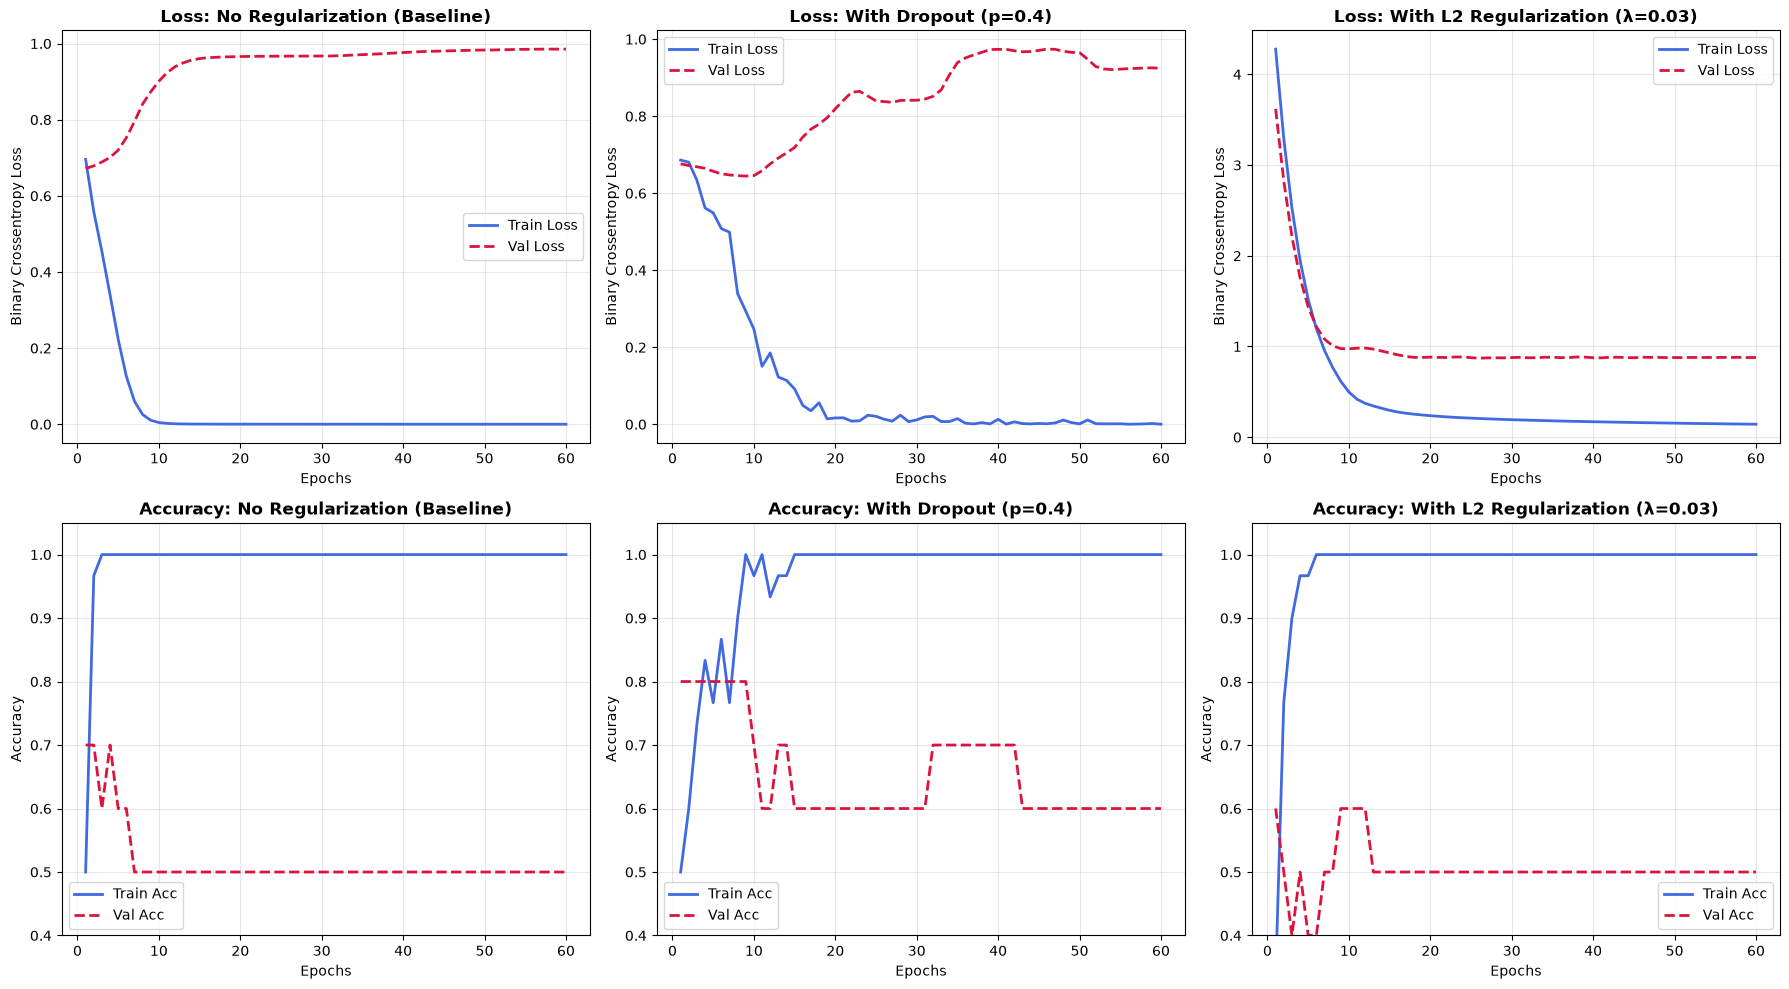


========================= MODEL PERFORMANCE SUMMARY =========================
            Model  Final Train Loss  Final Val Loss  Final Train Acc  Final Val Acc  Overfit Gap (Loss)
Baseline (No Reg)            0.0001          0.9855              1.0            0.5              0.9854
    Dropout (0.4)            0.0002          0.9245              1.0            0.6              0.9244
    L2 Reg (0.03)            0.1426          0.8787              1.0            0.5              0.7362


In [15]:
epochs_range = range(1, EPOCHS + 1)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

histories = [
    ("No Regularization (Baseline)", history_base),
    ("With Dropout (p=0.4)", history_dropout),
    ("With L2 Regularization (λ=0.03)", history_l2)
]

for col, (title, hist) in enumerate(histories):
    # Plot Losses
    axes[0, col].plot(epochs_range, hist.history["loss"], label="Train Loss", color="royalblue", lw=2)
    axes[0, col].plot(epochs_range, hist.history["val_loss"], label="Val Loss", color="crimson", lw=2, linestyle="--")
    axes[0, col].set_title(f"Loss: {title}", fontsize=12, fontweight="bold")
    axes[0, col].set_xlabel("Epochs")
    axes[0, col].set_ylabel("Binary Crossentropy Loss")
    axes[0, col].legend()
    axes[0, col].grid(True, alpha=0.3)
    
    # Plot Accuracies
    axes[1, col].plot(epochs_range, hist.history["accuracy"], label="Train Acc", color="royalblue", lw=2)
    axes[1, col].plot(epochs_range, hist.history["val_accuracy"], label="Val Acc", color="crimson", lw=2, linestyle="--")
    axes[1, col].set_title(f"Accuracy: {title}", fontsize=12, fontweight="bold")
    axes[1, col].set_xlabel("Epochs")
    axes[1, col].set_ylabel("Accuracy")
    axes[1, col].set_ylim([0.4, 1.05])
    axes[1, col].legend()
    axes[1, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary Table
summary_df = pd.DataFrame({
    "Model": ["Baseline (No Reg)", "Dropout (0.4)", "L2 Reg (0.03)"],
    "Final Train Loss": [history_base.history['loss'][-1], history_dropout.history['loss'][-1], history_l2.history['loss'][-1]],
    "Final Val Loss": [history_base.history['val_loss'][-1], history_dropout.history['val_loss'][-1], history_l2.history['val_loss'][-1]],
    "Final Train Acc": [history_base.history['accuracy'][-1], history_dropout.history['accuracy'][-1], history_l2.history['accuracy'][-1]],
    "Final Val Acc": [history_base.history['val_accuracy'][-1], history_dropout.history['val_accuracy'][-1], history_l2.history['val_accuracy'][-1]],
    "Overfit Gap (Loss)": [
        history_base.history['val_loss'][-1] - history_base.history['loss'][-1],
        history_dropout.history['val_loss'][-1] - history_dropout.history['loss'][-1],
        history_l2.history['val_loss'][-1] - history_l2.history['loss'][-1]
    ]
})

print("\n========================= MODEL PERFORMANCE SUMMARY =========================")
print(summary_df.round(4).to_string(index=False))